In [196]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import importlib
import multi_exp_log
sys.path.append('..')
import plot_settings

import GP

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [197]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [198]:

def read_raw_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )
    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)','soc_cell (1)']
    return df

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path_pulse = f'test_data_pulse300_50p'

data_pulse = read_raw_data(path_pulse)

# #rename columns
data_pulse.columns = ['u_par','C','t','V','I','F','u','Ue','soc']


data = read_data('2_merged_data')
# data['u'] = data['u'] * 1e5
# data['Rx'] = data['Rx'] * 1e-9
# data['I'] = data['I'] * 1.
# data['eta'] = data['V_t'] - data['ocv']
#data_pulse.describe()
# # remove the trajectories with u_par = 8.4, C = 3.6 and u_par = 25.7, C = 4.4 
# data = data[~((data['u_par'] == 8.4) & (data['C'] == 3.6))]
# data = data[~((data['u_par'] == 25.7) & (data['C'] == 4.4))]

#data.to_csv('Multi_data/4_raw_data.txt', index=False)


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_7195/2732270845.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [199]:
def group_trajectories(df):
    """
    Group trajectories by unique combinations of 'C' and 'u_par'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns 'C' and 'u_par'.

    Returns
    -------
    pd.DataFrame
        DataFrame with an added 'trajectory' column indicating group membership.
    """
    df['trajectory'] = df.groupby(['C', 'u_par'], sort=False).ngroup()
    return df

def merge_runs(n_runs, base_dir="Multi_data", add_run_id=False):
    """
    Merge multiple run files into one dataframe.

    Parameters
    ----------
    run_names : list[str]
        Run names without extension, e.g. ['1_run', '2_run'].
    base_dir : str
        Folder containing the .txt run files.
    add_run_id : bool
        If True, adds a 'run_id' column.

    Returns
    -------
    pd.DataFrame
        Merged and preprocessed dataframe.
    """
    run_names = []
    for n in range(1, n_runs+1):
        run_names.append(f"{n}_run")

    print(f"Merging runs: {run_names}")

    if not run_names:
        raise ValueError("run_names must contain at least one run name.")

    frames = []
    for run in run_names:
        df = pd.read_csv(
            f"{base_dir}/{run}_raw.txt",
            delim_whitespace=True,
            comment="%",
            header=None)
        df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue']

        # same preprocessing as in your notebook
        df['u'] = df['u'] * 1e5
        df['F'] = df['F'] * 1e-9
        df['I'] = df['I'] * 1.0
        df['eta'] = df['V'] - df['Ue']
        if add_run_id:
            df['run_id'] = run

        frames.append(df)

    merged = pd.concat(frames, ignore_index=True)
    # remove duplicates in C and u_par if they exist
    merged = merged.drop_duplicates(subset=['C', 'u_par', 't'])

    # optional global trajectory labeling across merged runs
    merged['trajectory'] = merged.groupby(['C', 'u_par'], sort=False).ngroup()

    return merged


# Example:
grouped_data_pulse = group_trajectories(data_pulse)
data_pulse = grouped_data_pulse.copy()

data_pulse['eta'] = data_pulse['V'] - data_pulse['Ue']
data_pulse['I'] = -data_pulse['I'] * 1.0
data_pulse['u'] = data_pulse['u'] * 1e5
data_pulse['F'] = -data_pulse['F'] * 1e-9
data_pulse.head()


,u_par,C,t,V,I,F,u,Ue,soc,trajectory,eta
0,12.0,2.6,0,4.267586,12.94336,0.916975,1.72479,4.324998,0.999999,0,-0.057412
1,12.0,2.6,1,4.191414,12.94336,0.916422,1.72479,4.322812,0.999282,0,-0.131398
2,12.0,2.6,2,4.172004,12.94336,0.915865,1.72479,4.320613,0.998559,0,-0.148609
3,12.0,2.6,3,4.162097,12.94336,0.915308,1.72479,4.318414,0.997837,0,-0.156317
4,12.0,2.6,4,4.154179,12.94336,0.914751,1.72479,4.316215,0.997115,0,-0.162036


In [200]:
print(len(data['trajectory'].unique()))
for tr in data['trajectory'].unique():
    print(f'Trajectory {tr}\t length: {(data['trajectory'] == tr).sum()}')

248
Trajectory 0	 length: 1476
Trajectory 1	 length: 758
Trajectory 2	 length: 5847
Trajectory 3	 length: 3846
Trajectory 4	 length: 758
Trajectory 5	 length: 3117
Trajectory 6	 length: 635
Trajectory 7	 length: 1840
Trajectory 8	 length: 1169
Trajectory 9	 length: 997
Trajectory 10	 length: 963
Trajectory 11	 length: 784
Trajectory 12	 length: 1172
Trajectory 13	 length: 4347
Trajectory 14	 length: 5847
Trajectory 15	 length: 1732
Trajectory 16	 length: 1038
Trajectory 17	 length: 673
Trajectory 18	 length: 1279
Trajectory 19	 length: 1402
Trajectory 20	 length: 586
Trajectory 21	 length: 1079
Trajectory 22	 length: 2089
Trajectory 23	 length: 3441
Trajectory 24	 length: 837
Trajectory 25	 length: 4987
Trajectory 26	 length: 713
Trajectory 27	 length: 570
Trajectory 28	 length: 865
Trajectory 29	 length: 1125
Trajectory 30	 length: 1552
Trajectory 31	 length: 2614
Trajectory 32	 length: 929
Trajectory 33	 length: 1955
Trajectory 34	 length: 810
Trajectory 35	 length: 1279
Trajectory 3

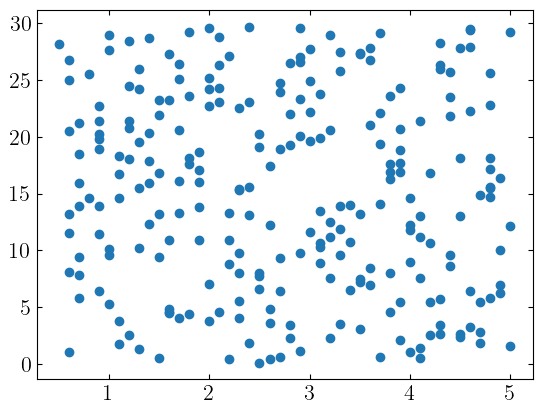

In [201]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

In [202]:

def find_duplicate_u_C_pairs(df):
    """
    Find duplicate (u_par, C) pairs in the dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'u_par' and 'C' columns.

    Returns
    -------
    pd.DataFrame
        Dataframe of duplicate (u_par, C) pairs and their counts.
    """
    duplicates = df.groupby(['u_par', 'C']).size().reset_index(name='count')
    duplicates = duplicates[duplicates['count'] > 1]
    return duplicates

duplicates = find_duplicate_u_C_pairs(u_C_pairs)
print("Duplicate (u_par, C) pairs:")
print(duplicates)

# # remove the duplicates
# for _, row in duplicates.iterrows():
#     u_par = row['u_par']
#     C = row['C']
#     # Find all trajectories with this (u_par, C) pair
#     trajectories_to_remove = data[(data['u_par'] == u_par) & (data['C'] == C)]['trajectory'].unique()
#     # Remove these trajectories from the dataframe
#     data = data[~data['trajectory'].isin(trajectories_to_remove)]

# print("After removing duplicates:")
# duplicates_after = find_duplicate_u_C_pairs(data.loc[data['t'] == 0, ['u_par', 'C']])
# print(duplicates_after)
 

Duplicate (u_par, C) pairs:
Empty DataFrame
Columns: [u_par, C, count]
Index: []


In [203]:
# Add finite-difference columns with the same length as `data`
dV = np.diff(data['V'].to_numpy())[:-1] / DT
dRx = np.diff(data['F'].to_numpy())[:-1] / DT

if len(dV) > 0:
    for i in range(2):
        dV = np.append(dV, dV[-1])
        dRx = np.append(dRx, dRx[-1])
else:
    dV = np.array([0.0])
    dRx = np.array([0.0])

data['dV'] = dV
data['dF'] = dRx

data.head()


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


In [204]:
def get_traj_data(trajectory, col,df = data):
    """
    Extract data for a specific trajectory.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a 'trajectory' column.
    trajectory : int
        The trajectory number to extract.

    Returns
    -------
    pd.DataFrame
        Dataframe containing only the data for the specified trajectory.
    """
    return df[col][df['trajectory'] == trajectory].reset_index(drop=True)

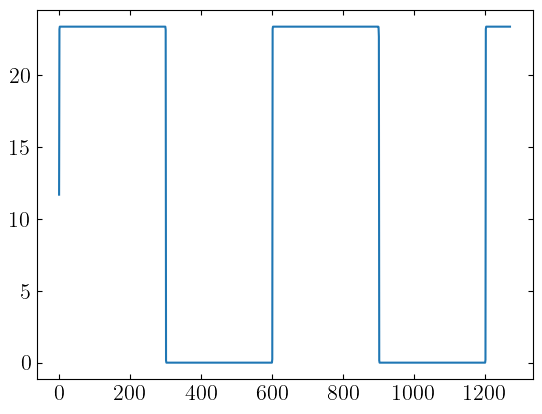

In [205]:
plt.plot(-np.concat(([0.5 * np.min(np.diff(get_traj_data(2, 'soc',df=data_pulse))) * Q0],np.diff(get_traj_data(2, 'soc',df=data_pulse)) * Q0)))

In [206]:
for tr in data_pulse['trajectory'].unique():
    data_pulse_tr = get_traj_data(tr, ['soc'], df=data_pulse)
    I_tr = -np.concat(([0.5 * np.min(np.diff(get_traj_data(tr, 'soc',df=data_pulse))) * Q0],np.diff(get_traj_data(tr, 'soc',df=data_pulse)) * Q0))
    data_pulse.loc[data_pulse['trajectory'] == tr, 'I'] = I_tr

#data_pulse.to_csv('Multi_data/mod_pulse_1.txt', index=False)

10.45425255584412
9.45860945418826


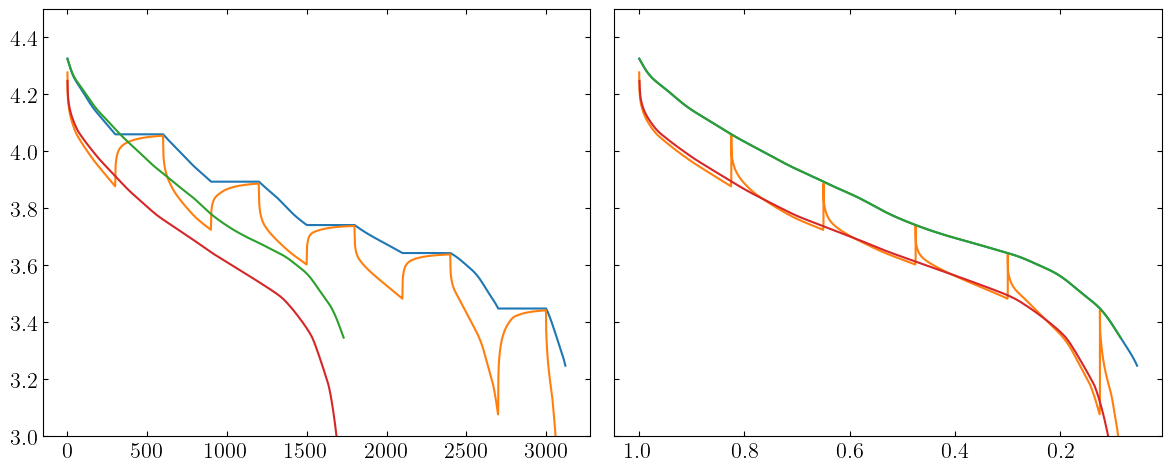

In [207]:
tr_max = 40
f,ax = plt.subplots(1, 2, figsize=(12, 5),sharey=True)
#plt.plot(get_traj_data(data, tr_max, 'soc'))
ax[0].plot(get_traj_data(tr_max,'t',df = data_pulse),GP.soc_to_Ue(get_traj_data(tr_max, 'soc',df = data_pulse),GP_FIT))
ax[0].plot(get_traj_data(tr_max,'t',df = data_pulse),get_traj_data(tr_max, 'V',df = data_pulse))
ax[1].plot(get_traj_data(tr_max,'soc',df = data_pulse),GP.soc_to_Ue(get_traj_data(tr_max, 'soc',df = data_pulse),GP_FIT))
ax[1].plot(get_traj_data(tr_max,'soc',df = data_pulse),get_traj_data(tr_max, 'V',df = data_pulse))
ax[1].invert_xaxis()
ax[0].set_ylim(3.0, 4.5)

print(get_traj_data(tr_max,'I',df = data_pulse).max())
tr_max = 15
ax[0].plot(get_traj_data(tr_max,'t'),GP.soc_to_Ue(get_traj_data(tr_max, 'soc'),GP_FIT))
ax[0].plot(get_traj_data(tr_max,'t'),get_traj_data(tr_max, 'V'))
ax[1].plot(get_traj_data(tr_max,'soc'),GP.soc_to_Ue(get_traj_data(tr_max, 'soc'),GP_FIT))
ax[1].plot(get_traj_data(tr_max,'soc'),get_traj_data(tr_max, 'V'))

print(get_traj_data(tr_max,'I').max())
plt.tight_layout()

GP sampling took 0.0505 seconds for 1732 points => 0.029 ms/point
MSE: 9.608565e-07


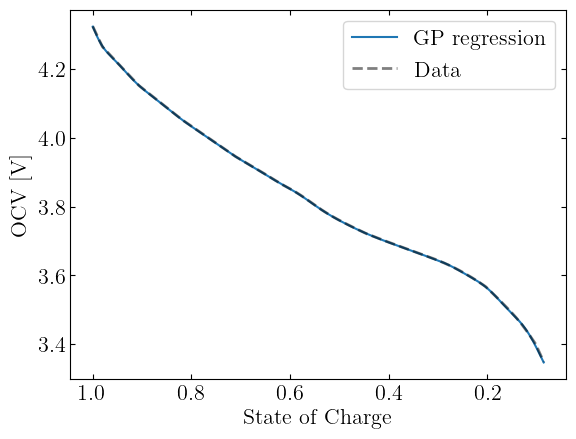

In [208]:

start = time.perf_counter()
ocv_sample = GP.soc_to_Ue(data['soc'][data['trajectory'] == tr_max].values,GP_FIT)
end = time.perf_counter()
print(f"GP sampling took {end - start:.4f} seconds for {len(data['soc'][data['trajectory'] == tr_max].values)} points => {len(data['soc'][data['trajectory'] == tr_max].values)**(-1) *1000* (end - start):.3f} ms/point")
plt.plot((data['soc'][data['trajectory'] == tr_max].values), ocv_sample, color = colors[0], label = 'GP regression')
plt.plot(data['soc'][data['trajectory'] == tr_max].values, data['Ue'][data['trajectory'] == tr_max].values, lw = 2, color = 'black', label = 'Data',ls = '--', alpha = 0.5)
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('OCV [V]')
plt.legend()
print(f'MSE: {np.mean((ocv_sample - data["Ue"][data["trajectory"] == tr_max].values)**2):.6e}')

# Plotting data

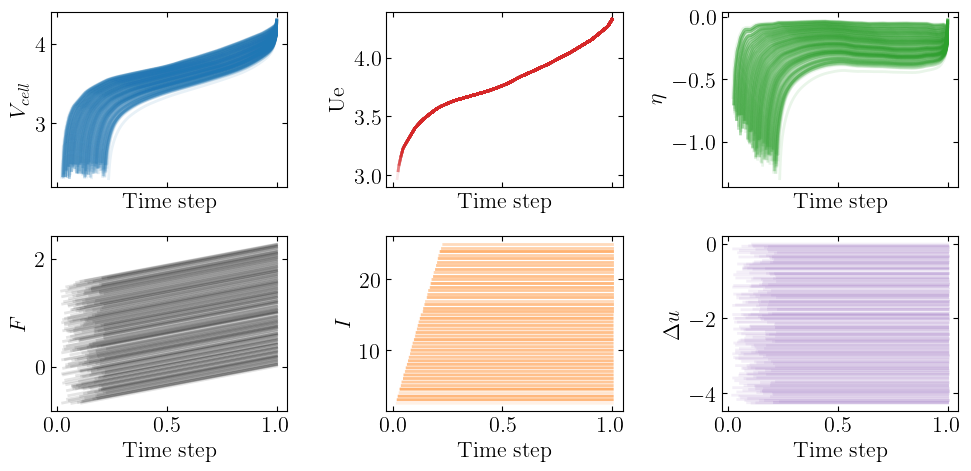

In [209]:


f, ax = plt.subplots(2, 3, figsize=(10, 5),sharex=True)
for plot_idx in range(data['trajectory'].nunique()):
    ax[0,0].plot(data['soc'][data['trajectory'] == plot_idx],data['V'][data['trajectory'] == plot_idx], '-', color = colors[0], lw = 2,alpha = 0.1)
    ax[0,0].set_xlabel('Time step')
    ax[0,0].set_ylabel('$V_{cell}$')
    ax[0,1].plot(data['soc'][data['trajectory'] == plot_idx],data['Ue'][data['trajectory'] == plot_idx], '-', color = colors[1], lw = 2,alpha = 0.1)
    ax[0,1].set_xlabel('Time step')
    ax[0,1].set_ylabel('Ue')
    ax[0,2].plot(data['soc'][data['trajectory'] == plot_idx],data['eta'][data['trajectory'] == plot_idx], '-', color = colors[2], lw = 2,alpha = 0.1)
    ax[0,2].set_xlabel('Time step')
    ax[0,2].set_ylabel(r'$\eta$')
    ax[1,0].plot(data['soc'][data['trajectory'] == plot_idx],data['F'][data['trajectory'] == plot_idx], lw = 2,color = colors[3],alpha = 0.1)
    ax[1,0].set_xlabel('Time step')
    ax[1,0].set_ylabel(r'$F$')
    ax[1,1].plot(data['soc'][data['trajectory'] == plot_idx],data['I'][data['trajectory'] == plot_idx], lw = 2,color = colors[4],alpha = 0.1)
    ax[1,1].set_xlabel('Time step')
    ax[1,1].set_ylabel(r'$I$')
    ax[1,2].plot(data['soc'][data['trajectory'] == plot_idx],data['u'][data['trajectory'] == plot_idx], lw = 2,color = colors[5],alpha = 0.1)
    ax[1,2].set_xlabel('Time step')
    ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()

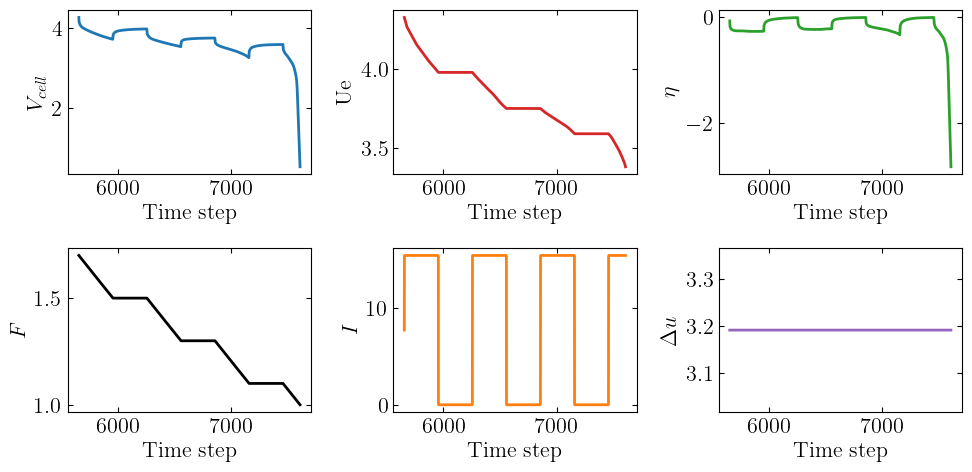

In [210]:
plot_idx = data_pulse['trajectory'] == 3
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data_pulse['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data_pulse['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data_pulse['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data_pulse['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data_pulse['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data_pulse['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

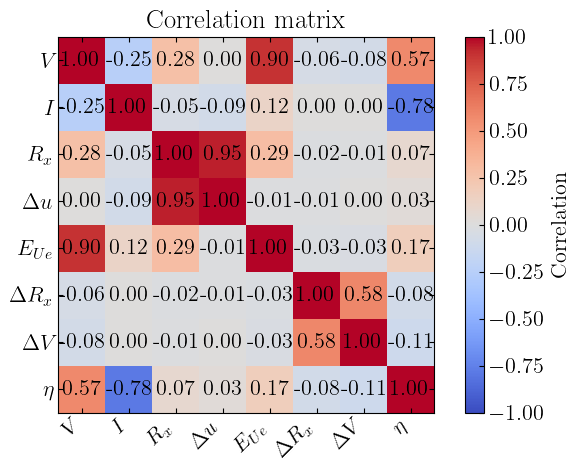

In [211]:
# Correlation matrix for current signals in this batch

X = data[['V','I','F','u_par','Ue','dF','dV','eta']].values
feature_names = ['$V$','$I$','$R_x$',r'$\Delta u$','$E_{Ue}$',r'$\Delta R_x$',r'$\Delta V$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.164 GN/mm


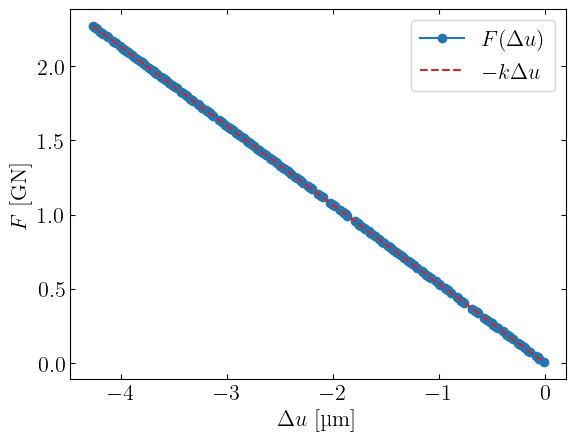

In [212]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['F'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['F']


first_F = data.groupby('u')['F'].first()
k = abs(first_F / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_F, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')


Text(0, 0.5, '$F$ [MN]')

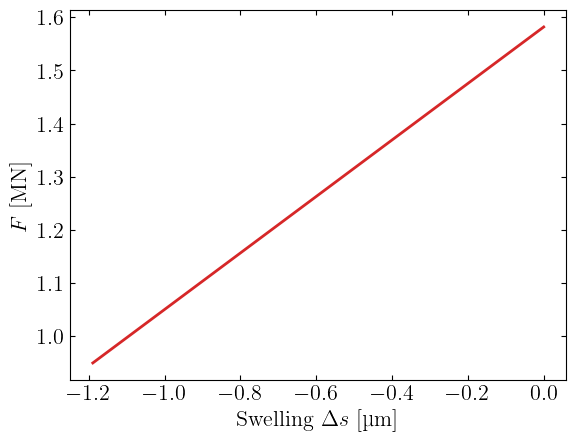

In [213]:
traj = 1

ds = data['F'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['F'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

In [214]:
N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values

In [215]:
N_trajs = len(data['trajectory'].unique())

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])


In [228]:
def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

def get_train_test(df):
    N_trajs = len(df['trajectory'].unique())
    x_tensor = torch.tensor(df[['I','u','soc','Ue','trajectory']].values, dtype=torch.float32)
    y_tensor = torch.tensor(df[['V','F','trajectory']].values, dtype=torch.float32)
    split = (df['trajectory']<=int(N_trajs *0.8)).sum()
    x_train, x_test = _split_flat(x_tensor, split); y_train, y_test = _split_flat(y_tensor, split)
    print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')
    print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')
    return x_train, y_train, x_test, y_test

In [229]:
x_train, y_train, x_test, y_test = get_train_test(data)
x_train_pulse, y_train_pulse, x_test_pulse, y_test_pulse = get_train_test(data_pulse)

Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])
Number of trajectories in train: 40 out of 50
X shape torch.Size([126623, 5])	y shape torch.Size([126623, 3])
X-train shape: torch.Size([99530, 5])	y-train shape: torch.Size([99530, 3])
X-test shape: torch.Size([27093, 5])	y-test shape: torch.Size([27093, 3])


In [224]:
import torch.nn.functional as TF

''' R1 '''

def ECM_model(Ue, I, R0, U1):
    #Ue = soc_to_Ue(soc,return_torch=True    )
    return Ue - I * R0 - U1

def Mech_model(u,Fs , k = k.values[0]):
    return -k * u + Fs

def soc_force_func(soc, variable = 'F'):
    
    if variable == 'F': 
        forcing_const = 0.9975
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp((soc-1) / (1 - forcing_const));

def R0_func(I,u):
    x0 = u
    x1 = I
    return x0*(-0.0001887521) - 7.049519e-5*x1 + 0.00844669;



class R1Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(R1Net, self).__init__()
        self.Snet = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if False:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            Fs_raw, R1_raw = self.Snet(x)[:,0], self.Snet(x)[:,1]
            soc = x[:,2]
            Fs = soc_force_func(soc) * Fs_raw
            R1 = TF.softplus(R1_raw) / 100  # Ensure R1 is non-negative

            return Fs, R1

modelR1 = R1Net()
optimizerR1 = optim.Adam(modelR1.parameters(), lr=1e-3)  

In [225]:
class C1Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(C1Net, self).__init__()
        self.Cnet = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if False:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:

            C_min = 1000
            C_max = 2e4
            C1_raw = self.Cnet(x)[:,0]

            C1 = C_min + TF.sigmoid(C1_raw) * (C_max - C_min) # Ensure R1 is non-negative and bounded between C_min and C_max

            return C1
        
modelC1 = C1Net()
optimizerC1 = optim.Adam(modelC1.parameters(), lr=1e-3)  

In [ ]:
def model(I,u,soc,Ue,case):
    R0 = R0_func(I,u)
    if case == 'R1':
        x = torch.stack((I,u,soc), dim=1)
        Fs, R1 = modelR1(x)
        U1 = R1 * I
    elif case == 'C1':
        U1 = torch.zeros_like(I)
        for t in range(1,len(I)):
            x = torch.tensor([I[t],u[t],soc[t]], dtype=torch.float32).unsqueeze(0)  # (1, 3)
            C1 = modelC1(x)  # (1,)
            R1 = modelR1(x)[1]  # (1,)
            U1[t] = U1[t-1] * (1 - 1 / (R1 * C1)) + I[t] / C1
    return torch.stack([ECM_model(Ue, I, R0, U1),Mech_model(u, Fs)], dim=1) 

In [ ]:
def get_NN_model(case):
    if case == 'R1':
        return modelR1
    elif case == 'C1':
        return modelC1
    else:
        raise ValueError(f"Unknown case: {case}. Valid cases are 'R1' and 'C1'.")

In [221]:
try: 
    print(summary(modelR1, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Error in model summary: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []


In [ ]:
def training(epochs=30, case='R1'):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

    NN_model.train()
    tot_time = 0.
    MAX_TIME_min = 3.5
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0

        for traj in range(int(N_trajs * 0.8)):

            x_traj = x_train[x_train[:, -1] == traj]
            y_traj = y_train[y_train[:, -1] == traj]

            # Inputs
            model_input = x_traj[:, :-1]      # (T, 3)
            model_target = y_traj[:,:-1]     # (T, 2)

            I   = model_input[:, 0]
            u   = model_input[:, 1]
            soc = model_input[:, 2]
            Ue  = model_input[:, 3]
            
            #Ue = soc_to_Ue(soc, return_torch=True)  # (T,)      

            # Forward
            y_pred = model(I,u,soc,Ue, case = case)                # (T, 2)

            V_loss = nn.MSELoss()(y_pred[:,0], model_target[:,0])
            F_loss = nn.MSELoss()(y_pred[:,1], model_target[:,1])
            #U_1_curve_loss = ((U1[2:] - 2*U1[1:-1] + U1[:-2])**2).mean()
            loss = V_loss + F_loss #+ 1e-2 * U_1_curve_loss
            #print(f'Traj {traj} | loss {loss.item():.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | U1_curve_loss {U_1_curve_loss.item():.2e}')
            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            ep_loss += loss.item()
            print(ep_loss)
        #print(f"Epoch {ep+1}/{epochs} | loss {ep_loss:.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | time {(time.perf_counter() - start_t):.2f}s")
        ep_loss /= N_trajs

        history["loss"].append(ep_loss)
        history["V_loss"].append(V_loss.item() / N_trajs)
        history["F_loss"].append(F_loss.item() / N_trajs)
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > MAX_TIME_min*60:
            print(f"Early stopping: Total training time exceeded {MAX_TIME_min} minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | time {end_t - start_t:.2f}s")

    return history      

In [ ]:
history = training(epochs=500)

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


ETA: 7.45 min
Epoch 1 | loss 1.77e-01 | V_loss 2.66e+01 | F_loss 5.23e-02 | time 0.89s
Epoch 2 | loss 5.87e-03 | V_loss 8.37e-01 | F_loss 4.33e-02 | time 0.94s
Epoch 3 | loss 3.28e-04 | V_loss 8.54e-03 | F_loss 4.07e-02 | time 0.97s
Epoch 4 | loss 3.19e-04 | V_loss 1.12e-02 | F_loss 3.66e-02 | time 0.81s
Epoch 5 | loss 4.52e-04 | V_loss 3.62e-02 | F_loss 3.15e-02 | time 0.90s
Epoch 6 | loss 3.46e-04 | V_loss 2.54e-02 | F_loss 2.66e-02 | time 0.83s
Epoch 7 | loss 3.47e-04 | V_loss 3.16e-02 | F_loss 2.05e-02 | time 0.84s
Epoch 8 | loss 1.28e-04 | V_loss 5.80e-03 | F_loss 1.34e-02 | time 0.85s
Epoch 9 | loss 1.93e-03 | V_loss 2.84e-01 | F_loss 5.27e-03 | time 0.76s
Epoch 10 | loss 8.00e-03 | V_loss 1.19e+00 | F_loss 4.97e-03 | time 0.77s
Epoch 11 | loss 3.99e-02 | V_loss 5.97e+00 | F_loss 8.59e-03 | time 0.82s
Epoch 12 | loss 9.91e-04 | V_loss 1.45e-01 | F_loss 3.49e-03 | time 0.99s
Epoch 13 | loss 2.73e-02 | V_loss 4.09e+00 | F_loss 1.70e-03 | time 0.98s
Epoch 14 | loss 8.44e-04 | V_loss

1.4191573796172935e-05


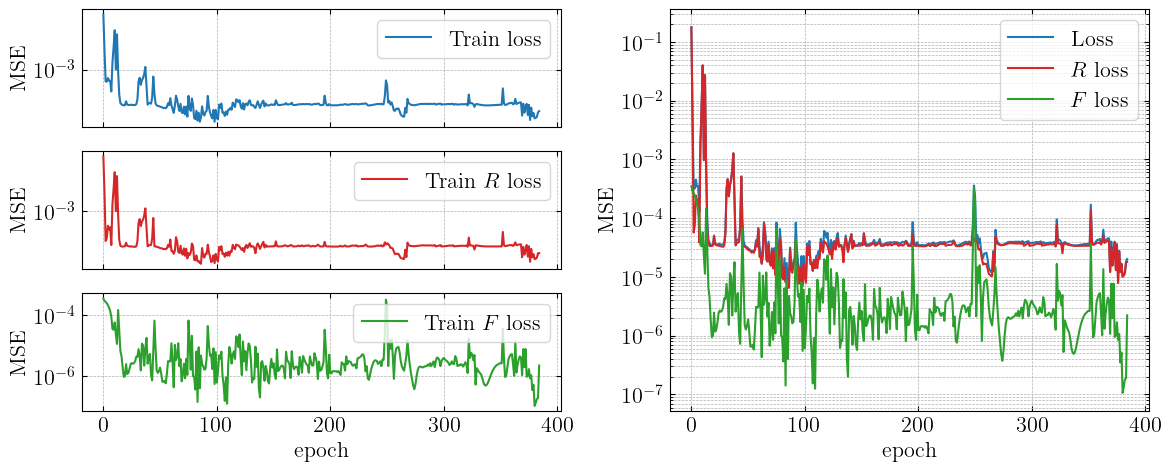

In [ ]:
print(np.mean(history['loss'][-5:]))

fig, ax = plt.subplot_mosaic(
    [
        ["loss", "combined"],
        ["V_loss", "combined"],
        ["F_loss", "combined"]
    ],
    figsize=(12, 5),
    sharex=True
)

# Individual plots
ax["loss"].semilogy(history["loss"], label="Train loss", color=colors[0])
ax["V_loss"].semilogy(history["V_loss"], label=r"Train $R$ loss", color=colors[1])
ax["F_loss"].semilogy(history["F_loss"], label=r"Train $F$ loss", color=colors[2])

# Combined plot (all together)
ax["combined"].semilogy(history["loss"], label="Loss", color=colors[0])
ax["combined"].semilogy(history["V_loss"], label=r"$R$ loss", color=colors[1])
ax["combined"].semilogy(history["F_loss"], label=r"$F$ loss", color=colors[2])

# Labels and styling
ax["F_loss"].set_xlabel("epoch")
ax["combined"].set_xlabel("epoch")

for key in ["loss", "V_loss", "F_loss", "combined"]:
    ax[key].set_ylabel("MSE")
    ax[key].legend()
    ax[key].grid(True, which="both", ls="--", lw=0.5)

plt.tight_layout()
plt.show()

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


KeyError: 'soc'

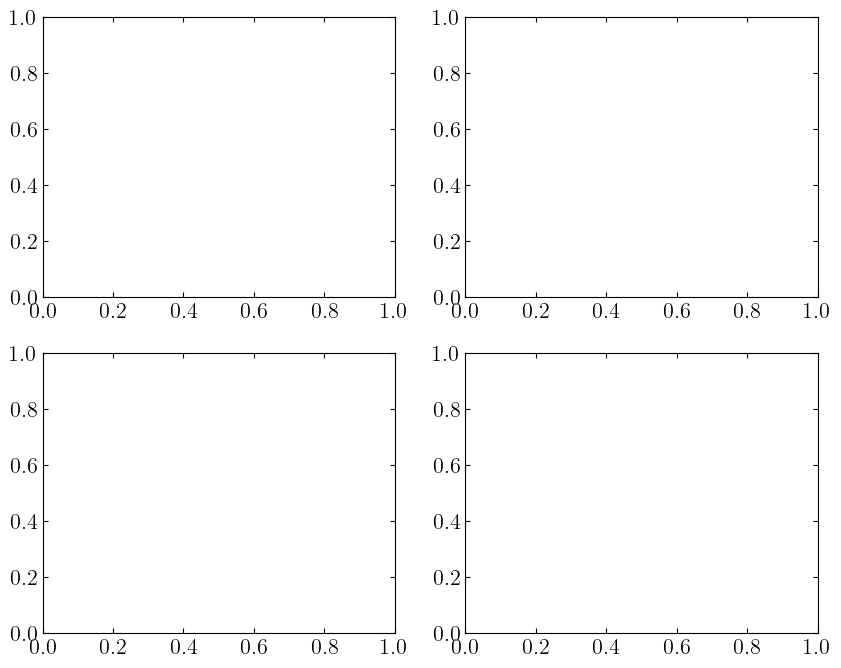

In [ ]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:,0]
        u = x_test[:,1]
        Ue = x_test[:,2]

        R0_pred, F_pred = model(x_test)
        y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)],dim=1)

        #test_loss = nn.MSELoss()(y_pred, y_test).item()
    #print(f"Test MSE: {test_loss:.3e}")
    return y_pred.detach().numpy(), R0_pred.detach().numpy(), F_pred.detach().numpy()   


traj_eval = 0
y_pred, R0, F = evaluate(model, x_train[x_train[:,-1] == traj_eval][:,:-1], y_train[y_train[:,2] == traj_eval][:,:-1])


f, ax = plt.subplots(2, 2, figsize=(10, 8))
#plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values, R0, label=r'Predicted $IR_0$',color = colors[0])
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values,-data['eta'][data['trajectory'] == traj_eval].values / x_train[x_train[:,-1] == traj_eval][:,0].numpy(), label=r'True $\eta$',color = colors[1],ls = '--')

ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['V_t'][data['trajectory'] == traj_eval].values, label=r'True $V_t$', color = colors[1],ls = '--')
ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,0], label=r'Predicted $V_t$', color = colors[0])

ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values, label=r'True $F$', color = colors[1],ls = '--')
ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,1], label=r'Predicted $F$', color = colors[0])    

ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values + k.values[0] * x_train[x_train[:,-1] == traj_eval][:,1].numpy(), label=r'True $F_s$', color = colors[1], ls = '--')
ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,F, label=r'Pred $F_s$', color = colors[0])

for a in ax.flat:
    a.set_xlabel('State of Charge')
    a.legend()
    a.invert_xaxis()
ax[0,0].set_ylabel(r'$\eta$ and $IR_0$')
ax[0,1].set_ylabel(r'$V_t$ [V]')
ax[1,0].set_ylabel(r'$F$ [GN]')
ax[1,1].set_ylabel(r'$-k\Delta u$ [GN]')
plt.tight_layout()

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


Test MSE: [2.997e-03,1.742e-04], RMSE: [5.475e-02,1.320e-02], MAE: [3.560e-02,1.260e-02], R2: [0.961,0.996]
Test MSE: [3.128e-03,1.720e-04], RMSE: [5.593e-02,1.311e-02], MAE: [3.581e-02,1.244e-02], R2: [0.959,0.996]
Test MSE: [2.460e-03,2.242e-04], RMSE: [4.959e-02,1.497e-02], MAE: [3.237e-02,1.449e-02], R2: [0.966,0.994]
Test MSE: [7.247e-03,3.670e-04], RMSE: [8.513e-02,1.916e-02], MAE: [4.569e-02,1.882e-02], R2: [0.902,0.989]
Test MSE: [1.632e-03,1.284e-04], RMSE: [4.040e-02,1.133e-02], MAE: [2.134e-02,1.109e-02], R2: [0.979,0.997]
Test MSE: [4.544e-03,2.556e-04], RMSE: [6.741e-02,1.599e-02], MAE: [4.501e-02,1.576e-02], R2: [0.939,0.993]
Test MSE: [2.344e-03,1.088e-04], RMSE: [4.841e-02,1.043e-02], MAE: [2.983e-02,1.005e-02], R2: [0.968,0.997]
Test MSE: [9.064e-03,6.240e-04], RMSE: [9.521e-02,2.498e-02], MAE: [6.498e-02,2.488e-02], R2: [0.882,0.979]
Test MSE: [4.637e-03,2.223e-04], RMSE: [6.810e-02,1.491e-02], MAE: [3.972e-02,1.466e-02], R2: [0.936,0.994]
Test MSE: [1.680e-03,5.945e-

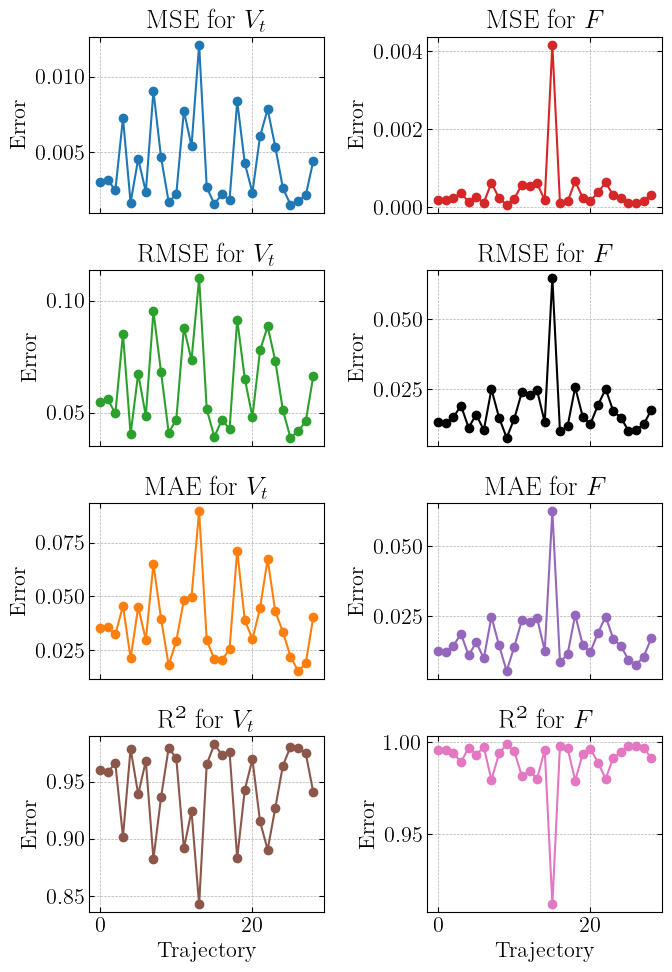

In [ ]:
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return mse, rmse, mae, r2


def evaluate_metrics(model, x, y):
    model.eval()
    mse = np.zeros((torch.unique(x[:, -1]).numel(),2))
    rmse = np.zeros_like(mse)
    mae = np.zeros_like(mse)
    r2 = np.zeros_like(mse)
    j = 0
    for traj in x[:,-1].unique():
        x_traj = x[x[:,-1] == traj][:,:-1]
        y_traj = y[y[:,-1] == traj][:,:-1]
        with torch.no_grad():
            I = x_traj[:,0]
            u = x_traj[:,1]
            Ue = x_traj[:,2]

            R0_pred, F_pred = model(x_traj)
            y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)],dim=1)

        y_true = y_traj.numpy()
        y_pred_np = y_pred.numpy()

        mse[j,0], rmse[j,0], mae[j,0], r2[j,0] = metrics(y_true[:,0], y_pred_np[:,0])
        mse[j,1], rmse[j,1], mae[j,1], r2[j,1] = metrics(y_true[:,1], y_pred_np[:,1])
        print(f"Test MSE: [{mse[j,0]:.3e},{mse[j,1]:.3e}], RMSE: [{rmse[j,0]:.3e},{rmse[j,1]:.3e}], MAE: [{mae[j,0]:.3e},{mae[j,1]:.3e}], R2: [{r2[j,0]:.3f},{r2[j,1]:.3f}]")
        j += 1
    return mse, rmse, mae, r2

mse, rmse, mae, r2 = evaluate_metrics(model, x_test, y_test)

f, ax = plt.subplots(4, 2, figsize=(7, 10),sharex=True)

ax[0,0].plot(mse[:,0], 'o-', color = colors[0])
ax[0,1].plot(mse[:,1], 'o-', color = colors[1])
ax[1,0].plot(rmse[:,0], 'o-', color = colors[2])
ax[1,1].plot(rmse[:,1], 'o-', color = colors[3])
ax[2,0].plot(mae[:,0], 'o-', color = colors[4])
ax[2,1].plot(mae[:,1], 'o-', color = colors[5])
ax[3,0].plot(r2[:,0], 'o-', color = colors[6])
ax[3,1].plot(r2[:,1], 'o-', color = colors[7])

ax[0,0].set_title('MSE for $V_t$')
ax[0,1].set_title('MSE for $F$')    
ax[1,0].set_title('RMSE for $V_t$')
ax[1,1].set_title('RMSE for $F$')
ax[2,0].set_title('MAE for $V_t$')
ax[2,1].set_title('MAE for $F$')
ax[3,0].set_title('R² for $V_t$')
ax[3,1].set_title('R² for $F$')
ax[3,0].set_xlabel('Trajectory')
ax[3,1].set_xlabel('Trajectory')
for a in ax.flat:
    a.set_ylabel('Error')
    a.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.show()
